In [1]:
import torch
import torch.nn as nn
import torchvision
import torchvision.transforms as transforms
from torchvision.utils import save_image, make_grid
import matplotlib.pyplot as plt
import numpy as np
from sklearn.decomposition import PCA
import os

In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


In [3]:
os.makedirs("generated_images", exist_ok=True)
os.makedirs("interpolations", exist_ok=True)

In [4]:
image_size = 64
batch_size = 64
latent_dim = 128

transform = transforms.Compose([
    transforms.Resize(image_size),
    transforms.CenterCrop(image_size),
    transforms.ToTensor(),
    transforms.Normalize((0.5,0.5,0.5),(0.5,0.5,0.5))
])

dataset = torchvision.datasets.CIFAR10(
    root="./data",
    train=True,
    download=True,
    transform=transform
)

dataloader = torch.utils.data.DataLoader(
    dataset,
    batch_size=batch_size,
    shuffle=True
)

print("Dataset loaded")

100%|██████████| 170M/170M [00:13<00:00, 12.9MB/s]


Dataset loaded


In [7]:
class MappingNetwork(nn.Module):

    def __init__(self, latent_dim, dlatent_dim=256):
        super().__init__()

        self.mapping = nn.Sequential(
            nn.Linear(latent_dim,256),
            nn.ReLU(),
            nn.Linear(256,256),
            nn.ReLU(),
            nn.Linear(256,dlatent_dim)
        )

    def forward(self,z):
        return self.mapping(z)

In [22]:
class Generator(nn.Module):

    def __init__(self, latent_dim, dlatent_dim=256):
        super().__init__()

        self.mapping = MappingNetwork(latent_dim,dlatent_dim)

        self.net = nn.Sequential(

            nn.ConvTranspose2d(dlatent_dim,256,4,1,0),
            nn.BatchNorm2d(256),
            nn.ReLU(True),

            nn.ConvTranspose2d(256,128,4,2,1),
            nn.BatchNorm2d(128),
            nn.ReLU(True),

            nn.ConvTranspose2d(128,64,4,2,1),
            nn.BatchNorm2d(64),
            nn.ReLU(True),

            nn.ConvTranspose2d(64,32,4,2,1), # Added this layer to upsample to 32x32
            nn.BatchNorm2d(32),
            nn.ReLU(True),

            nn.ConvTranspose2d(32,3,4,2,1), # This layer now upsamples to 64x64
            nn.Tanh()
        )

    def forward(self,z):

        w = self.mapping(z)

        w = w.view(w.size(0),w.size(1),1,1)

        img = self.net(w)

        return img

In [23]:
class Discriminator(nn.Module):

    def __init__(self):
        super().__init__()

        self.net = nn.Sequential(

            nn.Conv2d(3,64,4,2,1),
            nn.LeakyReLU(0.2),

            nn.Conv2d(64,128,4,2,1),
            nn.BatchNorm2d(128),
            nn.LeakyReLU(0.2),

            nn.Conv2d(128,256,4,2,1),
            nn.BatchNorm2d(256),
            nn.LeakyReLU(0.2),

            nn.Conv2d(256,1,8,1,0), # Changed kernel size from 4 to 8
            nn.Sigmoid()
        )

    def forward(self,x):
        return self.net(x).view(-1)

In [24]:
generator = Generator(latent_dim).to(device)
discriminator = Discriminator().to(device)

In [25]:
criterion = nn.BCELoss()

g_optimizer = torch.optim.Adam(generator.parameters(), lr=0.0002, betas=(0.5,0.999))
d_optimizer = torch.optim.Adam(discriminator.parameters(), lr=0.0002, betas=(0.5,0.999))

In [27]:
epochs = 10

for epoch in range(epochs):

    for real_images, _ in dataloader:

        real_images = real_images.to(device)
        batch_size = real_images.size(0)

        real_labels = torch.ones(batch_size).to(device)
        fake_labels = torch.zeros(batch_size).to(device)

        # Train Discriminator
        d_optimizer.zero_grad()

        outputs = discriminator(real_images)
        d_loss_real = criterion(outputs, real_labels)

        noise = torch.randn(batch_size, latent_dim).to(device)
        fake_images = generator(noise)

        outputs = discriminator(fake_images.detach())
        d_loss_fake = criterion(outputs, fake_labels)

        d_loss = d_loss_real + d_loss_fake
        d_loss.backward()

        d_optimizer.step()

        # Train Generator
        g_optimizer.zero_grad()

        outputs = discriminator(fake_images)
        g_loss = criterion(outputs, real_labels)

        g_loss.backward()

        g_optimizer.step()

    print(f"Epoch {epoch+1}/{epochs} | D Loss: {d_loss.item():.4f} | G Loss: {g_loss.item():.4f}")

Epoch 1/10 | D Loss: 0.2153 | G Loss: 4.1240
Epoch 2/10 | D Loss: 1.9338 | G Loss: 5.8021
Epoch 3/10 | D Loss: 0.6010 | G Loss: 3.1016
Epoch 4/10 | D Loss: 0.6425 | G Loss: 5.0124
Epoch 5/10 | D Loss: 1.0709 | G Loss: 1.8489
Epoch 6/10 | D Loss: 0.2871 | G Loss: 7.0152
Epoch 7/10 | D Loss: 0.1328 | G Loss: 4.0203
Epoch 8/10 | D Loss: 0.4428 | G Loss: 4.5091
Epoch 9/10 | D Loss: 0.4902 | G Loss: 3.3612
Epoch 10/10 | D Loss: 1.4197 | G Loss: 0.0867


In [28]:
noise = torch.randn(10, latent_dim).to(device)

with torch.no_grad():
    fake_images = generator(noise).cpu()

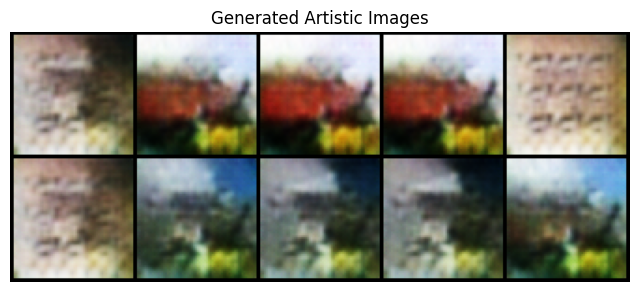

Images saved in generated_images folder


In [29]:
num_samples = 10

noise = torch.randn(num_samples, latent_dim).to(device)

with torch.no_grad():
    generated_images = generator(noise).detach().cpu()

# Display images
grid = make_grid(generated_images, nrow=5, normalize=True)

plt.figure(figsize=(8,8))
plt.title("Generated Artistic Images")
plt.axis("off")
plt.imshow(np.transpose(grid,(1,2,0)))
plt.show()

# Save images
save_image(
    generated_images,
    "generated_images/stylegan_samples.png",
    normalize=True,
    nrow=5
)

print("Images saved in generated_images folder")

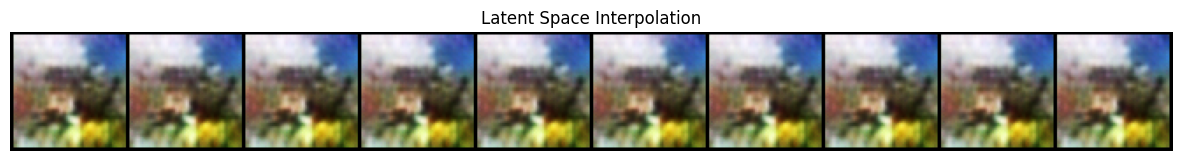

Interpolation saved in interpolations folder


In [30]:
z1 = torch.randn(1, latent_dim).to(device)
z2 = torch.randn(1, latent_dim).to(device)

alphas = torch.linspace(0,1,10)

images = []

for alpha in alphas:

    z = (1-alpha)*z1 + alpha*z2

    with torch.no_grad():
        img = generator(z).detach().cpu()

    images.append(img)

images = torch.cat(images)

# Display interpolation
grid = make_grid(images, nrow=10, normalize=True)

plt.figure(figsize=(15,3))
plt.title("Latent Space Interpolation")
plt.axis("off")
plt.imshow(np.transpose(grid,(1,2,0)))
plt.show()

# Save interpolation
save_image(
    images,
    "interpolations/stylegan_interpolation.png",
    normalize=True,
    nrow=10
)

print("Interpolation saved in interpolations folder")

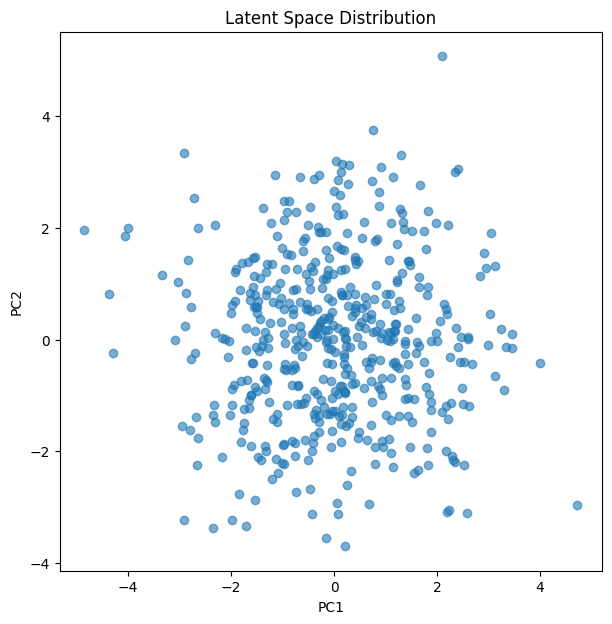

In [31]:
num_samples = 500

latent_vectors = torch.randn(num_samples, latent_dim)

pca = PCA(n_components=2)

latent_2d = pca.fit_transform(latent_vectors.numpy())

plt.figure(figsize=(7,7))
plt.scatter(latent_2d[:,0], latent_2d[:,1], alpha=0.6)
plt.title("Latent Space Distribution")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()